# Feature Selection

This notebook reuses the already preprocessed data from `Preprocessment.ipynb` and applies:
1. Pearson correlation (numeric features vs target)
2. Logistic Regression
3. Random Forest feature importance

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

TARGET_COL = "y"
RANDOM_STATE = 42

In [2]:
X_train = pd.read_csv(Path(r"data/X_train_processed.csv"))
X_test = pd.read_csv(Path(r"data/X_test_processed.csv"))
y_train = pd.read_csv(Path(r"data/y_train_processed.csv"))
y_test = pd.read_csv(Path(r"data/y_test_processed.csv"))

y_train = y_train.squeeze("columns")
y_test = y_test.squeeze("columns")


#drop the duration column
X_train.drop(columns=["duration"], inplace=True)
X_test.drop(columns=["duration"], inplace=True)


print(f"Train preprocessed shape: {X_train.shape}")
print(f"Test preprocessed shape:  {X_test.shape}")

Train preprocessed shape: (13423, 29)
Test preprocessed shape:  (9043, 29)


## Pearson Correlation filter method

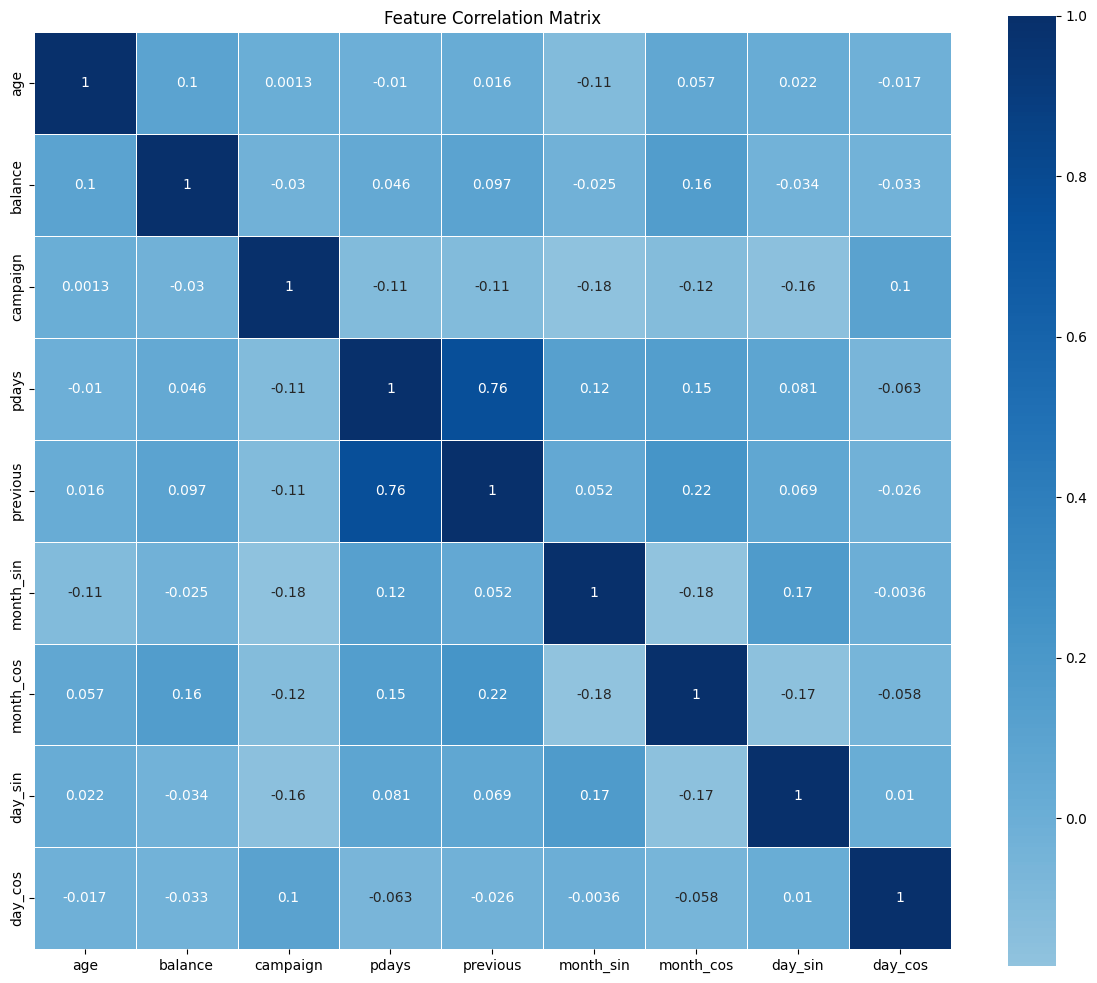

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# correlation matrix between features
corr_map = X_train[numeric_cols].corr()

# filter the variables with valuue_counts length greater than 2
filtered_cols = [col for col in numeric_cols if X_train[col].nunique() > 2]
filtered_corr_map = X_train[filtered_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    filtered_corr_map,
    cmap="Blues",
    center=0,
    square=True,
    annot=True,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [4]:
# combine features with target
corr_df = X_train.copy()
corr_df["target"] = y_train

# calculate Pearson correlation with target
pearson_corr = corr_df.corr()["target"].drop("target")

# Create a clean dataframe
pearson_corr_df = pd.DataFrame({
    "pearson_corr": pearson_corr,
    "abs_pearson_corr": pearson_corr.abs()
}).sort_values("abs_pearson_corr", ascending=False)

# Show top features
print("Top features by Pearson correlation with target:")
display(pearson_corr_df.head(20))


Top features by Pearson correlation with target:


,pearson_corr,abs_pearson_corr
poutcome_success,0.365856,0.365856
previous,0.351307,0.351307
housing_yes,-0.307611,0.307611
month_cos,0.283958,0.283958
pdays,0.230081,0.230081
balance,0.209116,0.209116
marital_single,0.200177,0.200177
marital_married,-0.189657,0.189657
job_blue-collar,-0.186507,0.186507
job_retired,0.174903,0.174903


In [5]:
## 2) Logistic Regression
for c in [1, 0.5, 0.1, 0.05, 0.01]:
    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=c,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    coefficients = pd.Series(model.coef_[0], index=X_train.columns)

    selected_features = coefficients[coefficients != 0].index.tolist()

    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    #print selected features with the length of the list and the value of c
    print(f"C: {c} - Selected features: {len(selected_features)} - {selected_features}")


C: 1 - Selected features: 28 - ['age', 'balance', 'campaign', 'pdays', 'previous', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'job_blue-collar', 'job_entrepreneur', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'poutcome_other', 'poutcome_success']
C: 0.5 - Selected features: 26 - ['age', 'balance', 'campaign', 'pdays', 'previous', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'job_blue-collar', 'job_management', 'job_retired', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'poutcome_other', 'poutcome_success']
C: 0.1 - Selected features: 23 - ['age', 'balance', 'campaign', 'previous', 'month_sin', 'm

## Random Forest Importance embedded method

In [6]:
# One-hot encode categoricals for Random Forest
X_train_encoded = X_train.copy()

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
    max_depth=5,
    max_features="sqrt",
)
rf.fit(X_train_encoded, y_train)

rf_importance_encoded = pd.Series(rf.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
rf_importance_encoded.head(30)

month_cos              0.147451
month_sin              0.146661
pdays                  0.120531
housing_yes            0.116197
previous               0.105044
poutcome_success       0.088863
age                    0.053704
balance                0.050743
marital_single         0.034310
day_sin                0.026712
marital_married        0.025734
campaign               0.025505
job_blue-collar        0.018909
education_tertiary     0.012719
job_student            0.006970
day_cos                0.006055
job_retired            0.005944
poutcome_other         0.002283
loan_yes               0.001928
contact_telephone      0.000731
education_secondary    0.000686
job_management         0.000620
job_services           0.000439
job_technician         0.000388
job_unemployed         0.000294
default_yes            0.000198
job_housemaid          0.000134
job_self-employed      0.000128
job_entrepreneur       0.000121
dtype: float64

In [7]:
TOP_K_RF = 30
selected_by_rf = rf_importance_encoded.head(TOP_K_RF).index.tolist()

print(f"Random Forest selected top-{TOP_K_RF} features: {len(selected_by_rf)}")
selected_by_rf

Random Forest selected top-30 features: 29


['month_cos',
 'month_sin',
 'pdays',
 'housing_yes',
 'previous',
 'poutcome_success',
 'age',
 'balance',
 'marital_single',
 'day_sin',
 'marital_married',
 'campaign',
 'job_blue-collar',
 'education_tertiary',
 'job_student',
 'day_cos',
 'job_retired',
 'poutcome_other',
 'loan_yes',
 'contact_telephone',
 'education_secondary',
 'job_management',
 'job_services',
 'job_technician',
 'job_unemployed',
 'default_yes',
 'job_housemaid',
 'job_self-employed',
 'job_entrepreneur']

In [8]:
X_traiun_rf_selected = X_train[selected_by_rf]
X_test_rf_selected = X_test[selected_by_rf]

## Final Selected Features

In [9]:
X_train.to_csv(Path(r"data/X_train_selected.csv"), index=False)
X_test.to_csv(Path(r"data/X_test_selected.csv"), index=False)
y_train.to_csv(Path(r"data/y_train.csv"), index=False)
y_test.to_csv(Path(r"data/y_test.csv"), index=False)